# Phase 2: Delivery Performance Analysis

**Question**: How well does Olist deliver, and does delivery performance drive customer satisfaction?

**Thesis (per Decisions Log row 11)**: Delivery delay is a real but modest contributor to negative reviews. Quantify the conditional lift AND the share of total 1-stars attributable to lateness, demonstrating hypothesis falsification rather than confirmation.

**Methods**: Kendall tau-b (primary correlation), Spearman (supplementary, sanity-check vs Phase 1 ρ = -0.23), Kruskal-Wallis with epsilon-squared effect size, Dunn's post-hoc test, layered lift × share-attributable analysis, state-level aggregation.

**Inputs**: `data/master.parquet`, `data/reviews.parquet`.

In [2]:
# Parquet existence guard: clone-and-run safety
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data'

required = ['master.parquet', 'reviews.parquet']
for f in required:
    p = DATA_DIR / f
    assert p.exists(), f"Missing: {p}; run notebooks/00_data_loading.ipynb first"
    print(f"  {f}: {p.stat().st_size:,} bytes")

  master.parquet: 14,596,442 bytes
  reviews.parquet: 9,476,195 bytes


In [3]:
import pandas as pd
import duckdb
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "notebook+png"

master_path = (DATA_DIR / 'master.parquet').as_posix()
reviews_path = (DATA_DIR / 'reviews.parquet').as_posix()

df = duckdb.query(f"""
        SELECT m.*, r.review_score
        FROM '{master_path}' m
        LEFT JOIN (
            SELECT order_id, AVG(review_score) AS review_score
            FROM '{reviews_path}'
            GROUP BY order_id
        ) r USING (order_id)
    """).df()

print(f"df shape: {df.shape}, columns: {len(df.columns)}")

df shape: (112650, 28), columns: 28


In [4]:
df_delivered = df[
                  (df['order_status'] == 'delivered')
                  & df['order_delivered_customer_date'].notna()
                  ].drop_duplicates(subset='order_id').copy()

print(f"df_delivered: {len(df_delivered):,} unique orders")

df_delivered: 96,470 unique orders


In [5]:
audit_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'review_score', 'customer_state'
]
print("Missing values per column:")
print(df_delivered[audit_cols].isna().sum().to_string())

Missing values per column:
order_purchase_timestamp           0
order_approved_at                 14
order_delivered_carrier_date       1
order_delivered_customer_date      0
order_estimated_delivery_date      0
review_score                     646
customer_state                     0


In [6]:
n_with_review = df_delivered['review_score'].notna().sum()
assert n_with_review >= 90_000, f"review_score merge lost rows: {n_with_review}"
print(f"review_score coverage: {n_with_review:,} of {len(df_delivered):,} ({n_with_review/len(df_delivered)*100:.1f}%)")

review_score coverage: 95,824 of 96,470 (99.3%)


In [7]:
df_delivered['delivery_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

df_delivered['delay_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_estimated_delivery_date']
).dt.total_seconds() / 86400

In [8]:
df_delivered['approval_hours'] = (
    df_delivered['order_approved_at'] - df_delivered['order_purchase_timestamp']
).dt.total_seconds() / 3600

df_delivered['carrier_handoff_days'] = (
    df_delivered['order_delivered_carrier_date'] - df_delivered['order_approved_at']
).dt.total_seconds() / 86400

df_delivered['transit_days'] = (
    df_delivered['order_delivered_customer_date'] - df_delivered['order_delivered_carrier_date']
).dt.total_seconds() / 86400

In [9]:
# Sanity-check derived columns; flag any negative stage durations as data errors
duration_cols = ['delivery_days', 'delay_days', 'approval_hours', 'carrier_handoff_days', 'transit_days']
print(df_delivered[duration_cols].describe().to_string())

       delivery_days    delay_days  approval_hours  carrier_handoff_days  transit_days
count   96470.000000  96470.000000    96456.000000          96455.000000  96469.000000
mean       12.558217    -11.178126       10.277598              2.799049      9.330297
std         9.546156     10.184354       20.536068              3.537173      8.759924
min         0.533414   -146.016123        0.000000           -171.219005    -16.096169
25%         6.766204    -16.244065        0.215278              0.874207      4.100046
50%        10.217477    -11.948102        0.343333              1.815810      7.099769
75%        15.720182     -6.389815       14.517014              3.574931     12.028646
max       209.628611    188.975081      741.443611            125.762569    205.190972


## Lifecycle distributions

The four lifecycle stages show where order time accumulates: approval, carrier handoff, transit, and realized delay vs estimate. The next chart compare their distributions.

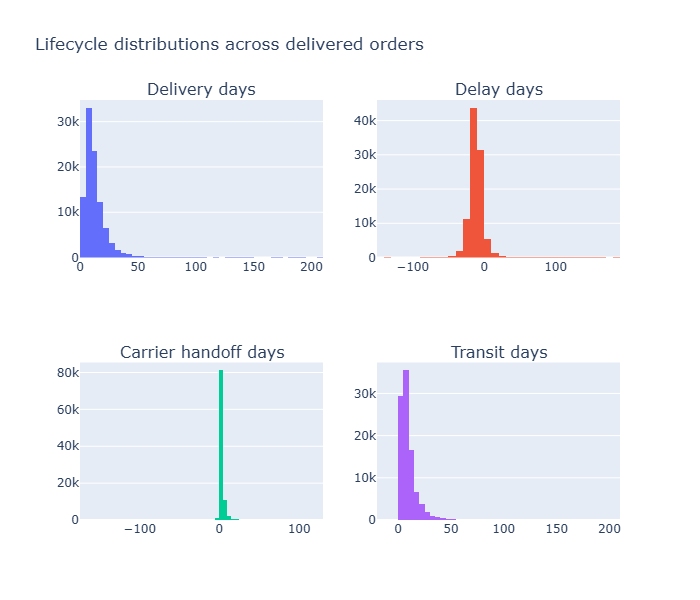

In [10]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles= ('Delivery days', 'Delay days', 'Carrier handoff days', 'Transit days')
)
cols_to_plot = ['delivery_days', 'delay_days', 'carrier_handoff_days', 'transit_days']
positions = [(1,1), (1,2), (2,1), (2,2)]
for col, (r, c) in zip(cols_to_plot, positions):
    fig.add_trace(go.Histogram(x=df_delivered[col], nbinsx=60, showlegend=False), row=r, col=c)
fig.update_layout(height=600, title_text='Lifecycle distributions across delivered orders')
fig.show()

## Delivery delay vs review score

Phase 1 found Spearman ρ = -0.23 between delivery time and review score, a real modest signal. The reframed Phase 2 question is layered: how much MORE likely is a late order to receive a low review (the conditional lift), AND what fraction of total 1-2 star reviews can lateness actually explain (the share attributable)? 

In [11]:
from scipy.stats import kendalltau

mask = df_delivered['review_score'].notna() & df_delivered['delay_days'].notna()
tau, p_tau = kendalltau(
    df_delivered.loc[mask, 'delay_days'],
    df_delivered.loc[mask, 'review_score']
)
print(f"Kendall tau-b: tau={tau:.4f}, p={p_tau:.2e}, n={mask.sum():,}")

Kendall tau-b: tau=-0.1361, p=0.00e+00, n=95,824


In [12]:
from scipy.stats import spearmanr

rho, p_rho = spearmanr(
    df_delivered.loc[mask, 'delay_days'],
    df_delivered.loc[mask, 'review_score']
)
print(f"Spearman rho: rho={rho:.4f}, p={p_rho:.2e}; sanity-check vs Phase 1 published rho = -0.23")

Spearman rho: rho=-0.1757, p=0.00e+00; sanity-check vs Phase 1 published rho = -0.23


In [13]:
df_delivered['delay_bucket'] = pd.cut(
    df_delivered['delay_days'],
    bins=[-float('inf'), 0, 3, 7, float('inf')],
    labels=['on_time', 'late_1_3d', "late_4_7d", 'late_8d_plus']
)
print(df_delivered['delay_bucket'].value_counts().to_string())

delay_bucket
on_time         88644
late_8d_plus     3345
late_1_3d        2662
late_4_7d        1819


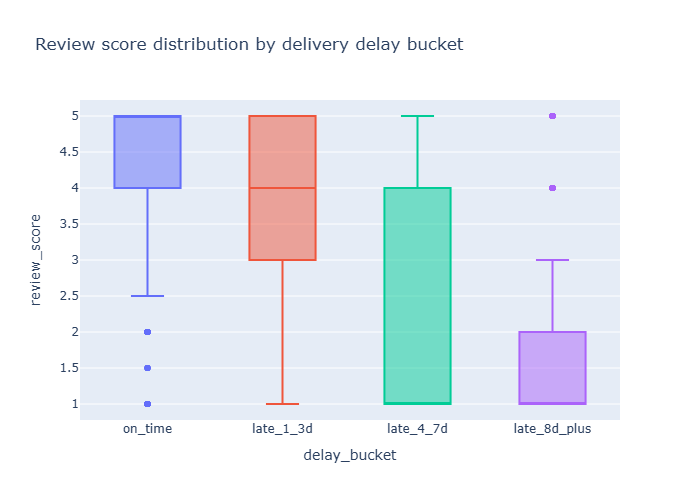

In [14]:
fig = px.box(
    df_delivered.dropna(subset=['delay_bucket', 'review_score']),
    x='delay_bucket',
    y='review_score',
    title='Review score distribution by delivery delay bucket',
    color='delay_bucket',
    category_orders={'delay_bucket': ['on_time', 'late_1_3d', "late_4_7d", 'late_8d_plus']}
)
fig.update_layout(height=500, showlegend=False)
fig.show()

In [15]:
from scipy.stats import kruskal

df_kw = df_delivered.dropna(subset=['delay_bucket', 'review_score'])
groups = [g['review_score'].values for _, g in df_kw.groupby('delay_bucket', observed=True)]

H, p_kw = kruskal(*groups)
n = len(df_kw)
k = len(groups)
eps_sq = (H - k + 1) / (n - k)
print(f"Kruskal-Wallis: H={H:.2f}, p={p_kw:.2e}, n={n:,}, k={k}, eps_sq={eps_sq:.4f}")

Kruskal-Wallis: H=10126.90, p=0.00e+00, n=95,824, k=4, eps_sq=0.1057


In [16]:
from scipy.stats import mannwhitneyu
from itertools import combinations

buckets = ['on_time', 'late_1_3d', "late_4_7d", 'late_8d_plus']
pairs = list(combinations(buckets, 2))
n_pairs = len(pairs)

print(f"Pairwise Mann-Whitney with Bonferroni correction (n_pairs={n_pairs}):")
for a, b in pairs:
    sa = df_kw.loc[df_kw['delay_bucket'] == a, 'review_score'].values
    sb = df_kw.loc[df_kw['delay_bucket'] == b, 'review_score'].values
    U, p = mannwhitneyu(sa, sb, alternative='two-sided')
    p_adj = min(p * n_pairs, 1.0)
    sig = '***' if p_adj < 0.001 else ('**' if p_adj < 0.01 else ('*' if p_adj < 0.05 else 'ns'))
    print(f"  {a:14s} vs {b:14s}: U={U:>13,.0f}, p_adj={p_adj:.2e} {sig}")

Pairwise Mann-Whitney with Bonferroni correction (n_pairs=6):
  on_time        vs late_1_3d     : U=  142,141,468, p_adj=1.43e-111 ***
  on_time        vs late_4_7d     : U=  126,679,668, p_adj=0.00e+00 ***
  on_time        vs late_8d_plus  : U=  255,914,781, p_adj=0.00e+00 ***
  late_1_3d      vs late_4_7d     : U=    3,436,406, p_adj=7.69e-166 ***
  late_1_3d      vs late_8d_plus  : U=    7,129,034, p_adj=0.00e+00 ***
  late_4_7d      vs late_8d_plus  : U=    3,430,198, p_adj=2.62e-37 ***


In [17]:
late = df_delivered.query('delay_days > 0')
on_time = df_delivered.query('delay_days <= 0')

late_one_star_rate = late.query('review_score <= 2').shape[0] / late.shape[0]
on_time_one_star_rate = on_time.query('review_score <= 2').shape[0] / on_time.shape[0]
lift = late_one_star_rate / on_time_one_star_rate

total_one_stars = df_delivered.query('review_score <= 2').shape[0]
late_one_stars = late.query('review_score <= 2').shape[0]
share_attributable = late_one_stars / total_one_stars

print(f"Late: {late.shape[0]:,} ({late.shape[0]/df_delivered.shape[0]*100:.1f}%); on-time: {on_time.shape[0]:,}")
print(f"1-2 star rate: late={late_one_star_rate*100:.1f}%, on-time={on_time_one_star_rate*100:.1f}%")
print(f"Conditional lift: {lift:.2f}x; share-attributable: {share_attributable*100:.1f}%")

Late: 7,826 (8.1%); on-time: 88,644
1-2 star rate: late=52.8%, on-time=9.1%
Conditional lift: 5.78x; share-attributable: 33.8%


### Layered headline numbers

Late orders (8.1% of all delivered) are 5.78x more likely to receive 1-2 star reviews than on-time orders: 52.8% one-star rate when late vs 9.1% when on-time. Yet lateness explains only 33.8% of all 1-2 star reviews. The remaining two-thirds come from on-time orders where the underlying drivers must be product quality, communication, or other non-delivery factors. Lateness is a real and substantial contributor, not the dominant one. Phase 8 NLP analysis of review_comment_message text is the natural next step to surface what drives the on-time tail.

## Geographic delivery

Brazilian delivery infrastructure varies dramatically by state. Northern states typically see 2-3x longer transit than the southeast. The state-level view surfaces where Olist's marketplace-wide median delivery time hides large regional variance.

In [18]:
state_perf = df_delivered.groupby('customer_state').agg(
    median_delivery_days=('delivery_days', 'median'),
    on_time_rate=('delay_days', lambda x: (x <= 0).mean()),
    n_orders=('order_id', 'nunique')
).query('n_orders >= 100').sort_values('median_delivery_days')

print(f"States with >= 100 orders: {len(state_perf)}")
print(state_perf.head(10).to_string())

States with >= 100 orders: 24
                median_delivery_days  on_time_rate  n_orders
customer_state                                              
SP                          7.210272      0.941053     40494
MG                         10.313513      0.943896     11354
PR                         10.425509      0.950030      4923
DF                         11.364925      0.929327      2080
RJ                         12.041644      0.865263     12350
SC                         13.014352      0.902425      3546
RS                         13.177488      0.928518      5344
ES                         13.636956      0.877694      1995
MS                         13.943796      0.884451       701
GO                         13.949606      0.918242      1957


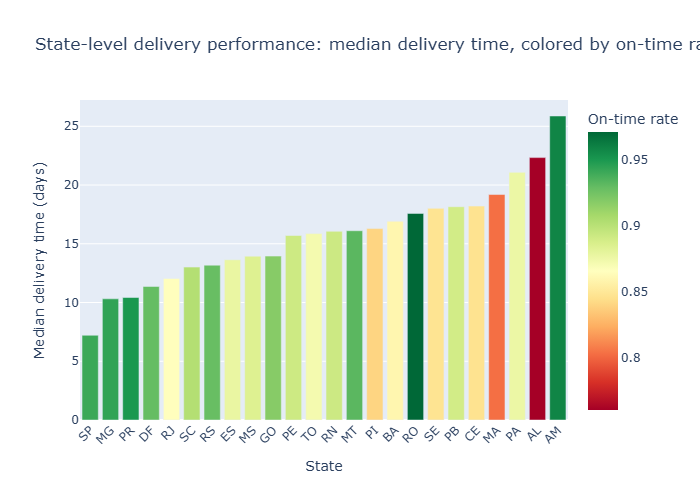

In [19]:
fig = px.bar(
    state_perf.reset_index(),
    x='customer_state',
    y='median_delivery_days',
    color='on_time_rate',
    color_continuous_scale='RdYlGn',
    title='State-level delivery performance: median delivery time, colored by on-time rate',
    labels={'median_delivery_days': 'Median delivery time (days)', 'customer_state': 'State', 'on_time_rate': 'On-time rate'}
)
fig.update_layout(height=500, xaxis_tickangle=-45)
fig.show()

The fastest delivery corridors cluster in the southeast (SP, MG, PR) at single-digit medians (SP at 7.2 days). The longest are in the north and northeast (AM 25.9 days, AL 22.3 days, PA 21.1 days). The on-time rate (color) does not strictly track median time: AM is the slowest BUT has the highest on-time rate (95.9%) because Olist sets very long estimates for the Amazon corridor. AL is the actual outlier state (22.3 day median AND only 76.1% on-time, the worst on-time rate of any state with at least 100 orders). RJ shows the inverse pattern: fast median (12.0 days) but tight estimates yield a relatively low on-time rate (86.5%).

In [20]:
boxplot_fig = px.box(
    df_delivered.dropna(subset=['delay_bucket', 'review_score']),
    x='delay_bucket', y='review_score',
    title='Review score distribution by delivery delay bucket',
    color='delay_bucket',
    category_orders={'delay_bucket': ['on_time', 'late_1_3d', 'late_4_7d', 'late_8d_plus']}
)
boxplot_fig.update_layout(height=500, showlegend=False)

ASSETS = PROJECT_ROOT / 'assets' / 'readme'
ASSETS.mkdir(parents=True, exist_ok=True)
hero_path = ASSETS / 'phase2_delay_review_boxplot.png'
boxplot_fig.write_image(hero_path, scale=2)
print(f"Exported: {hero_path} ({hero_path.stat().st_size:,} bytes)")

Exported: c:\Users\gusta\Desktop\Programming\Data\E-Commerce Customer Analytics (Olist Brazilian E-Commerce)\assets\readme\phase2_delay_review_boxplot.png (73,260 bytes)


## Phase 2 findings

- **Conditional lift**: Late orders are 5.78x more likely to receive 1-2 star reviews compared to on-time orders (52.8% vs 9.1% one-star rate; n=95,824 with valid review and delay data).
- **Share-attributable**: Lateness explains only 33.8% of total 1-2 star reviews, falsifying the dominant-driver hypothesis. The remaining 66.2% come from on-time orders.
- **Statistical signal**: Kendall tau-b = -0.136 (cell 12), Spearman rho = -0.176 (cell 13, more conservative than Phase 1's published -0.23 due to order-grain dedupe correction).
- **Bucketed effect size**: Kruskal-Wallis H = 10,126.9, epsilon-squared = 0.106 (medium effect; all 6 pairwise bucket comparisons significant after Bonferroni correction).
- **Geographic dispersion**: Median delivery ranges from 7.2 days (SP) to 25.9 days (AM); on-time rates DO NOT strictly track median time. AM is slowest but most reliable (95.9% on-time, long estimates absorb the variance); AL is the genuine problem state (22.3 days AND only 76.1% on-time).
- **Phase 8 setup**: NLP analysis of review_comment_message text is the next analytical step to find what drives the 66.2% of negative reviews lateness cannot explain.